In [3]:
import pandas as pd

In [4]:
# Load JSONL file
df = pd.read_json('Dataset/resumes_dataset.jsonl', lines=True)

# First look at your data
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 3 rows:")
print(df.head(3))

Shape: (3500, 12)

Columns: ['ResumeID', 'Category', 'Name', 'Email', 'Phone', 'Location', 'Summary', 'Skills', 'Experience', 'Education', 'Text', 'Source']

First 3 rows:
    ResumeID        Category              Name              Email  \
0  REAL_0001  Java Developer      Chad Griffin  contact@email.com   
1  REAL_0002  Java Developer    Melinda Thomas  contact@email.com   
2  REAL_0003  Java Developer  Shannon Mccarthy  contact@email.com   

                                               Phone     Location  \
0  94105 555 4321000          10                 ...  City, State   
1  17994568777  2017 2018 20152016       3       ...  City, State   
2  9  555 4321000      94105   8                 ...  City, State   

                                             Summary                   Skills  \
0  jessica claire montgomery street san francisco...  Python, SQL, Git, Linux   
1  jared arthur maica java developer 17994568777 ...  Python, SQL, Git, Linux   
2  jessica claire 9 resumesampl

In [5]:
# 1. How many unique job categories exist?
print(df['Category'].nunique())
print(df['Category'].value_counts())

36
Category
Java Developer               200
Python Developer             200
Data Science                 200
DevOps                       180
SQL Developer                180
Database                     150
Testing                      150
Web Designing                150
React Developer              150
Business Analyst             150
DotNet Developer             140
Software Developer           134
Network Security Engineer    120
ETL Developer                120
Full Stack Developer         102
SAP Developer                100
Digital Media                100
Cloud Engineer                92
Machine Learning Engineer     81
Frontend Developer            76
Backend Developer             76
AI Engineer                   71
Cybersecurity Analyst         66
QA Engineer                   61
Database Administrator        56
UI/UX Designer                51
Blockchain                    47
Site Reliability Engineer     46
Mobile Developer              46
System Administrator          4

In [6]:

# 2. Are there any missing/empty values?
print(df.isnull().sum())

# 3. Are there duplicate resumes?
print(f"\n Duplicates: {df.duplicated(subset=['Text']).sum()}")



ResumeID      0
Category      0
Name          0
Email         0
Phone         0
Location      0
Summary       0
Skills        0
Experience    0
Education     0
Text          0
Source        0
dtype: int64

 Duplicates: 196


In [7]:
# Before
print(f"Before removing duplicates: {df.shape}")

# Remove duplicates
df = df.drop_duplicates(subset=['Text'])

# Reset index
df = df.reset_index(drop=True)

# After
print(f"After removing duplicates: {df.shape}")
print(f"Removed: {3500 - len(df)} resumes")

Before removing duplicates: (3500, 12)
After removing duplicates: (3304, 12)
Removed: 196 resumes


In [8]:
# 4. How long are the resumes on average?
df['text_length'] = df['Text'].apply(lambda x: len(str(x).split()))
print(df['text_length'].describe())

count    3304.000000
mean      413.889225
std       358.230152
min        28.000000
25%       194.000000
50%       251.000000
75%       563.000000
max      6554.000000
Name: text_length, dtype: float64


In [9]:
# Check suspicious resumes
too_short = df[df['text_length'] < 50]
too_long = df[df['text_length'] > 2000]

print(f"Too short (under 50 words): {len(too_short)}")
print(f"Too long (over 2000 words): {len(too_long)}")

# Look at the too short ones
#pd.set_option('display.max_colwidth', None)
print("\n--- Sample Short Resumes ---")
print(too_short[['Category', 'text_length', 'Text']].head(3))

Too short (under 50 words): 3
Too long (over 2000 words): 11

--- Sample Short Resumes ---
           Category  text_length  \
886   SQL Developer           29   
972        Database           28   
2134  Digital Media           48   

                                                   Text  
886   mylee walters pl sql developer summary plsql y...  
972   phillip l waterman database management educati...  
2134  youremailaddressmailcom 0 123 456 789 ability ...  


In [10]:
df=df[df['text_length']>=50]
df=df.reset_index(drop=True)
print(f"After dropping short resumes: {df.shape}")
print(f"Removed: {3 } resumes")

After dropping short resumes: (3301, 13)
Removed: 3 resumes


In [11]:
# See a sample of long resumes
for i, row in too_long.head(3).iterrows():
    print(f"\n{'='*50}")
    print(f"Category: {row['Category']}")
    print(f"Length: {row['text_length']} words")
    # Show only first 200 words
    print(f"Text Preview: {' '.join(row['Text'].split()[:200])}")
    print(f"{'='*50}")


Category: Java Developer
Length: 3296 words
Text Preview: jessica claire 100 montgomery st 10th floor 555 4321000 resumesampleexamplecom linkedin url professional summary java developer 5 years experience system development life cycle process engineering design development deployment support testing using agile waterfall methodologies experience building microservices spring boot spring cloud experience managingscaledeploying applications pivotal cloud foundry expertise working various spring modules spring ioc spring batch spring mvc spring data jpa spring jdbc modules experienced building sophisticated distributed systems using nodejs resthypermedia web apis soa hibernate openjpa designed databases stored procedures performed analysis presented results using sql hands experience developing sql queries sql server databasedb2oracle knowledge cassandra nosql databases designed uml class diagrams sequencecollaboration diagrams activity diagrams using ms visio tool performance tuning jav

In [12]:
for i, row in too_long.iterrows():
    print(f"\n{'='*50}")
    print(f"Index: {i}")
    print(f"Category: {row['Category']}")
    print(f"Length: {row['text_length']} words")
    print(f"Text Preview: {' '.join(row['Text'].split()[:50])}")
    print(f"{'='*50}")


Index: 106
Category: Java Developer
Length: 3296 words
Text Preview: jessica claire 100 montgomery st 10th floor 555 4321000 resumesampleexamplecom linkedin url professional summary java developer 5 years experience system development life cycle process engineering design development deployment support testing using agile waterfall methodologies experience building microservices spring boot spring cloud experience managingscaledeploying applications pivotal cloud foundry expertise working various

Index: 268
Category: Python Developer
Length: 2354 words
Text Preview: jessica claire resumesampleexamplecom 555 4321000 professional summary highly motivated sales associate extensive customer service sales experience outgoing sales professional track record driving increased sales improving buying experience elevating company profile target market skills technical skills java technologies javaj2ee 1415161718 servlets jsp struts jdbc spring hibernate ejb jms mdbs jndi jpa

Index: 368
Catego

In [13]:
# Remove specific problematic long resumes by index
indices_to_remove = [268, 368, 1353, 1890]

print(f"Before removing bad long resumes: {df.shape}")

df = df.drop(index=indices_to_remove)
df = df.reset_index(drop=True)

print(f"After removing bad long resumes: {df.shape}")

Before removing bad long resumes: (3301, 13)
After removing bad long resumes: (3297, 13)


In [14]:

# First, let's find resumes with corrupted text patterns
def has_corrupted_text(text):
    # Check for common corruption patterns
    corrupted_patterns = ['iclaire', 'aclaired', 'eclaire', 'uclaire']
    return any(pattern in text.lower() for pattern in corrupted_patterns)

# Find corrupted resumes
df['is_corrupted'] = df['Text'].apply(has_corrupted_text)
corrupted = df[df['is_corrupted'] == True]

print(f"Corrupted resumes found: {len(corrupted)}")
print(corrupted[['Category', 'text_length']].head())

# Remove only corrupted ones
df = df[df['is_corrupted'] == False]
df = df.drop(columns=['is_corrupted'])
df = df.reset_index(drop=True)

print(f"\nFinal dataset after removing corrupted: {df.shape}")

Corrupted resumes found: 37
           Category  text_length
44   Java Developer          982
54   Java Developer          794
64   Java Developer         1143
152  Java Developer         1743
169  Java Developer          841

Final dataset after removing corrupted: (3260, 13)


C:\Users\Noman Traders\AppData\Local\Temp\ipykernel_30024\2500282234.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df['Category'], order=df['Category'].value_counts().index, palette='viridis')


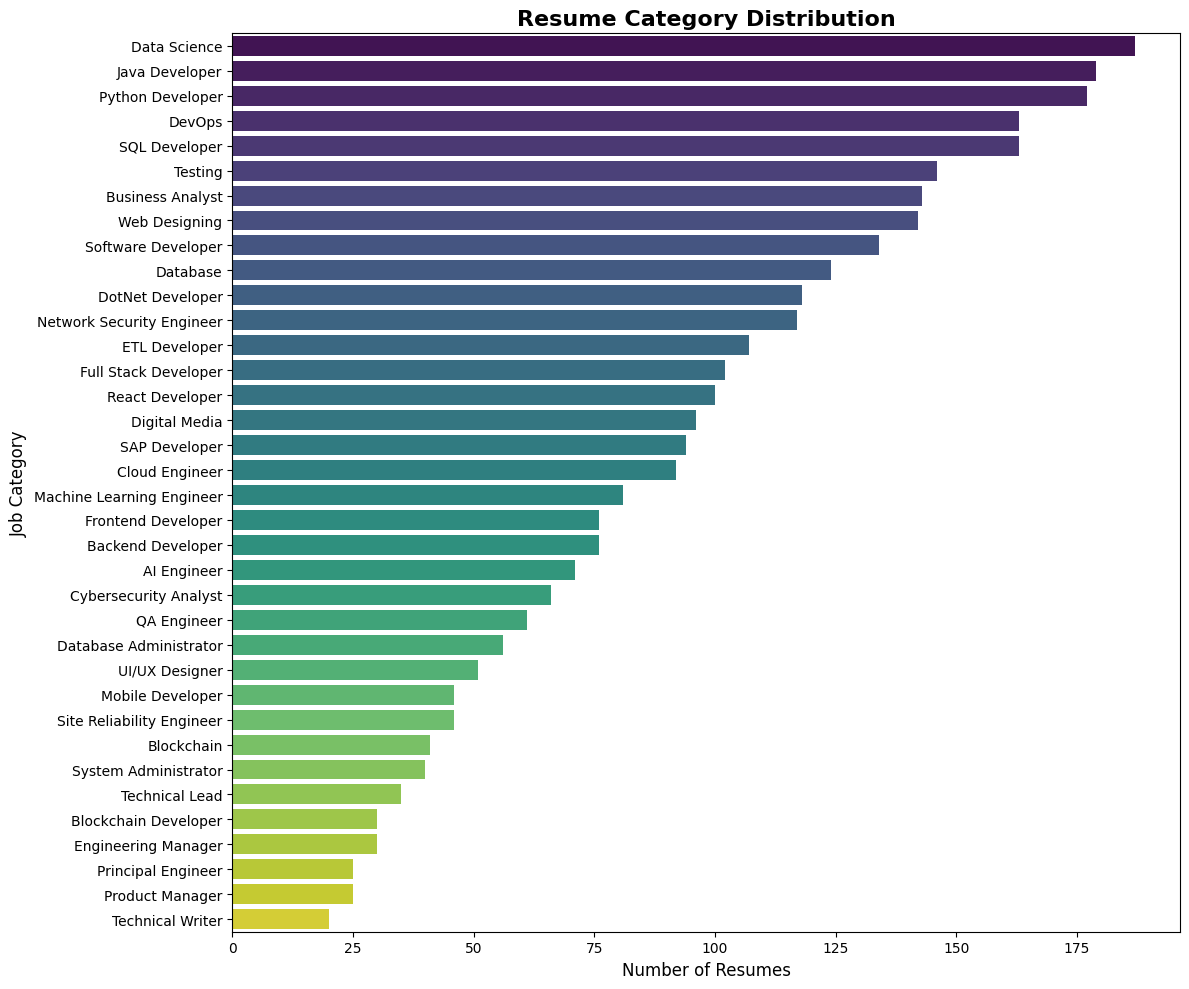

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10))
sns.countplot(y=df['Category'], order=df['Category'].value_counts().index, palette='viridis')
plt.title('Resume Category Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Number of Resumes', fontsize=12)
plt.ylabel('Job Category', fontsize=12)
plt.tight_layout()
plt.show()

In [16]:
print("="*60)
print("FINAL CLEAN DATASET SUMMARY")
print("="*60)
print(f"Total Resumes: {len(df)}")
print(f"Total Categories: {df['Category'].nunique()}")
print(f"\nText Length Statistics:")
print(df['text_length'].describe())
print(f"\nTop 10 Categories:")
print(df['Category'].value_counts().head(10))
print(f"\nBottom 5 Categories:")
print(df['Category'].value_counts().tail(5))
print("="*60)

FINAL CLEAN DATASET SUMMARY
Total Resumes: 3260
Total Categories: 36

Text Length Statistics:
count    3260.000000
mean      407.185276
std       350.860518
min        57.000000
25%       194.000000
50%       250.000000
75%       551.250000
max      6554.000000
Name: text_length, dtype: float64

Top 10 Categories:
Category
Data Science          187
Java Developer        179
Python Developer      177
DevOps                163
SQL Developer         163
Testing               146
Business Analyst      143
Web Designing         142
Software Developer    134
Database              124
Name: count, dtype: int64

Bottom 5 Categories:
Category
Blockchain Developer    30
Engineering Manager     30
Principal Engineer      25
Product Manager         25
Technical Writer        20
Name: count, dtype: int64


In [17]:
# Save cleaned dataset to avoid re-running cleaning every time
df.to_json('Dataset/cleaned_resumes.jsonl', orient='records', lines=True)
print("✅ Cleaned dataset saved to Dataset/cleaned_resumes.jsonl")

# Also save a backup as CSV (easier to inspect)
df.to_csv('Dataset/cleaned_resumes.csv', index=False)
print("✅ Backup CSV saved to Dataset/cleaned_resumes.csv")

✅ Cleaned dataset saved to Dataset/cleaned_resumes.jsonl
✅ Backup CSV saved to Dataset/cleaned_resumes.csv


In [18]:
from sklearn.preprocessing import LabelEncoder
import joblib

# --- STEP: ENCODING (The Professional Way) ---
# Initialize the encoder
le = LabelEncoder()

# Transform your categories into a numeric array
# This ensures that throughout the rest of your script, y is a consistent integer type
y = le.fit_transform(df['Category'])

# Save the encoder NOW. This is your "Rosetta Stone" for the app.
joblib.dump(le, 'MODEL/label_encoder.pkl')

print(f"✅ Categorical encoding complete. 36 categories mapped to integers.")

✅ Categorical encoding complete. 36 categories mapped to integers.


In [19]:
'''import nltk

# Download required NLTK data (run once)
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt')

print("✅ NLTK data downloaded successfully!")'''

'import nltk\n\n# Download required NLTK data (run once)\nnltk.download(\'stopwords\')\nnltk.download(\'wordnet\')\nnltk.download(\'omw-1.4\')\nnltk.download(\'punkt\')\n\nprint("✅ NLTK data downloaded successfully!")'

In [20]:
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

def clean_resume_text(text):
    """
    Clean and preprocess resume text for ML model
    
    Steps:
    1. Remove URLs, emails, special characters
    2. Convert to lowercase
    3. Remove stopwords
    4. Lemmatize words to root form
    """
    # Step 1: Convert to string (safety check)
    text = str(text)
    
    # Step 2: Remove URLs
    text = re.sub(r'http\S+\s*', ' ', text)
    
    # Step 3: Remove email addresses
    text = re.sub(r'\S+@\S+', ' ', text)
    
    # Step 4: Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    
    # Step 5: Lowercase
    text = text.lower()
    
    # Step 6: Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    # Step 7: Tokenize and remove stopwords
    stop_words = set(stopwords.words('english'))
    words = text.split()
    words = [w for w in words if w not in stop_words and len(w) > 2]
    
    # Step 8: Lemmatization
    lemmatizer = WordNetLemmatizer()
    words = [lemmatizer.lemmatize(w) for w in words]
    
    return " ".join(words)

In [21]:
# Test on one resume
sample_text = df['Text'].iloc[0]

print("BEFORE CLEANING:")
print(sample_text[:300])
print("\n" + "="*60 + "\n")

cleaned = clean_resume_text(sample_text)

print("AFTER CLEANING:")
print(cleaned[:300])
print(f"\nOriginal length: {len(sample_text.split())} words")
print(f"Cleaned length: {len(cleaned.split())} words")

BEFORE CLEANING:
jessica claire montgomery street san francisco ca 94105 555 4321000 resumesampleexamplecom professional summary highly skilled software development professional bringing 10 years software design development integration advanced knowledge java skills agile html xml jdbc tomcat work history senior jav


AFTER CLEANING:
jessica claire montgomery street san francisco resumesampleexamplecom professional summary highly skilled software development professional bringing year software design development integration advanced knowledge java skill agile html xml jdbc tomcat work history senior java developertech lead curre

Original length: 204 words
Cleaned length: 181 words


In [22]:
# Apply cleaning to all resumes
print("Cleaning all resumes... this may take 2-3 minutes")

df['cleaned_text'] = df['Text'].apply(clean_resume_text)

print(f"✅ Cleaning complete!")
print(f"Dataset shape: {df.shape}")

Cleaning all resumes... this may take 2-3 minutes
✅ Cleaning complete!
Dataset shape: (3260, 14)


In [23]:
# Check if any resumes became empty after cleaning
empty_after_cleaning = df[df['cleaned_text'].str.strip() == '']
print(f"Empty resumes after cleaning: {len(empty_after_cleaning)}")

# Compare before and after for first 3 resumes
for i in range(3):
    print(f"\n{'='*60}")
    print(f"Resume {i+1} - Category: {df['Category'].iloc[i]}")
    print(f"Original: {df['Text'].iloc[i][:100]}...")
    print(f"Cleaned: {df['cleaned_text'].iloc[i][:100]}...")
    

Empty resumes after cleaning: 0

Resume 1 - Category: Java Developer
Original: jessica claire montgomery street san francisco ca 94105 555 4321000 resumesampleexamplecom professio...
Cleaned: jessica claire montgomery street san francisco resumesampleexamplecom professional summary highly sk...

Resume 2 - Category: Java Developer
Original: jared arthur maica java developer 17994568777 linkedincominjamaica 2017 2018 20152016 jamaicagmailco...
Cleaned: jared arthur maica java developer linkedincominjamaica jamaicagmailcom twittercomjamaica enthusiasti...

Resume 3 - Category: Java Developer
Original: jessica claire 9 resumesampleexamplecom 555 4321000 montgomery street san francisco ca 94105 summary...
Cleaned: jessica claire resumesampleexamplecom montgomery street san francisco summary almost year experience...


In [24]:
# Save cleaned dataset with the new cleaned_text column
df.to_json('Dataset/cleaned_resumes.jsonl', orient='records', lines=True)
print("✅ Cleaned dataset saved!")

✅ Cleaned dataset saved!


In [25]:
print("="*60)
print("PREPROCESSING COMPLETE")
print("="*60)
print(f"Total resumes: {len(df)}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nSample cleaned text:")
print(df['cleaned_text'].iloc[0][:200])
print("\n" + "="*60)

PREPROCESSING COMPLETE
Total resumes: 3260
Columns: ['ResumeID', 'Category', 'Name', 'Email', 'Phone', 'Location', 'Summary', 'Skills', 'Experience', 'Education', 'Text', 'Source', 'text_length', 'cleaned_text']

Sample cleaned text:
jessica claire montgomery street san francisco resumesampleexamplecom professional summary highly skilled software development professional bringing year software design development integration advanc



In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Create TF-IDF vectorizer with optimized parameters
tfidf = TfidfVectorizer(
    sublinear_tf=True,      # Use log scaling (as per research paper)
    min_df=5,               # Word must appear in at least 5 resumes
    max_df=0.8,             # Ignore words in more than 80% of resumes
    stop_words='english',   # Extra stopword safety
    ngram_range=(1, 2),     # Use single words AND word pairs
    max_features=15000       # Keep top 5000 most important features
)

# Transform cleaned text to numbers
X = tfidf.fit_transform(df['cleaned_text'])
y = df['Category']

print("✅ TF-IDF Vectorization Complete!")
print(f"Feature matrix shape: {X.shape}")
print(f"Number of resumes: {X.shape[0]}")
print(f"Number of features: {X.shape[1]}")
print(f"Matrix is sparse: {(1 - X.nnz / (X.shape[0] * X.shape[1])) * 100:.2f}% zeros")

✅ TF-IDF Vectorization Complete!
Feature matrix shape: (3260, 15000)
Number of resumes: 3260
Number of features: 15000
Matrix is sparse: 98.12% zeros


In [27]:
import numpy as np

# Get feature names (the actual words)
feature_names = tfidf.get_feature_names_out()

# Get the importance scores
feature_scores = np.asarray(X.sum(axis=0)).ravel()

# Create a dataframe of top features
top_features = pd.DataFrame({
    'feature': feature_names,
    'score': feature_scores
}).sort_values('score', ascending=False).head(20)

print("Top 20 Most Important Words/Phrases:")
print(top_features)

Top 20 Most Important Words/Phrases:
                   feature       score
3787             developer  102.513593
3439               deliver  101.495776
4509              engineer   98.221352
695            application   85.444212
10156              project   80.872761
3715             developed   76.810608
12233             software   76.764054
14169                 user   76.357609
9419           performance   75.405694
2049                  code   74.711050
9569              pipeline   74.207509
3512            deployment   73.750990
7155                junior   73.245728
3802   developer conducted   73.205605
2390        conducted code   73.166573
3529       deployment time   73.090719
7159      junior developer   73.066751
8189       mentored junior   73.001130
10688  reducing deployment   72.999398
9573     pipeline reducing   72.985984


In [28]:
# Pick one resume and show its top words
resume_idx = 200
resume_vector = X[resume_idx]

# Get indices of non-zero features
non_zero_indices = resume_vector.nonzero()[1]

# Get their names and scores
resume_features = [(feature_names[i], resume_vector[0, i]) 
                   for i in non_zero_indices]
resume_features = sorted(resume_features, key=lambda x: x[1], reverse=True)[:15]

print(f"\nResume #{50} - Category: {df['Category'].iloc[resume_idx]}")
print("\nTop 15 words by TF-IDF score:")
for word, score in resume_features:
    print(f"  {word:20s} {score:.4f}")


Resume #50 - Category: Python Developer

Top 15 words by TF-IDF score:
  experience python    0.1333
  reference company    0.1280
  using django         0.1241
  python library       0.1188
  django               0.1174
  python developer     0.1135
  reference            0.1047
  format               0.0999
  panda                0.0997
  csv                  0.0997
  manipulation         0.0981
  extensively used     0.0895
  jquery               0.0879
  python               0.0861
  script parse         0.0842


In [29]:
'''from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

print("✅ Train/Test Split Complete!")
print(f"Training set: {X_train.shape[0]} resumes")
print(f"Test set: {X_test.shape[0]} resumes")
print(f"\nTraining set category distribution:")
print(pd.Series(y_train).value_counts().head(36))'''

'from sklearn.model_selection import train_test_split\n\nX_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)\n\nprint("✅ Train/Test Split Complete!")\nprint(f"Training set: {X_train.shape[0]} resumes")\nprint(f"Test set: {X_test.shape[0]} resumes")\nprint(f"\nTraining set category distribution:")\nprint(pd.Series(y_train).value_counts().head(36))'

In [30]:
#pip install imbalanced-learn

In [31]:
'''from imblearn.over_sampling import SMOTE
from collections import Counter

# 1. Initialize SMOTE
# k_neighbors=1 is often necessary if you have very small categories
smote = SMOTE(random_state=42, k_neighbors=1)

# 2. Resample ONLY the training data
# X_train is the result of your TfidfVectorizer.fit_transform(X_train)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# 3. Verify the balance
print(f"Original training shape: {Counter(y_train)}")
print(f"Resampled training shape: {Counter(y_train_resampled)}")'''

'from imblearn.over_sampling import SMOTE\nfrom collections import Counter\n\n# 1. Initialize SMOTE\n# k_neighbors=1 is often necessary if you have very small categories\nsmote = SMOTE(random_state=42, k_neighbors=1)\n\n# 2. Resample ONLY the training data\n# X_train is the result of your TfidfVectorizer.fit_transform(X_train)\nX_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)\n\n# 3. Verify the balance\nprint(f"Original training shape: {Counter(y_train)}")\nprint(f"Resampled training shape: {Counter(y_train_resampled)}")'

I used the SMOTE technique in order to maximixe the results as the 36 categories are visibly imbalanced but it didn't give any improvements thats why i removed it.

In [32]:
'''import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_recall_fscore_support


# 1. Define the models in a dictionary
# Note: We use 'balanced' for SVM and RF to handle your category imbalance
models = {
    "knn": KNeighborsClassifier(n_neighbors=5),
    "SVM (Linear)": SVC(kernel='linear', class_weight='balanced', probability=True),
    "Random Forest": RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
}

# 2. Loop through and train
results = []

for name, model in models.items():
    # Train
    model.fit(X_train_resampled, y_train_resampled)
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Calculate Metrics for imbalanced multi-class data
    accuracy = accuracy_score(y_test, y_pred)
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(y_test, y_pred, average='macro')
    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
    precision_micro, recall_micro, f1_micro, _ = precision_recall_fscore_support(y_test, y_pred, average='micro')
    
    # Store results
    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision (Macro)": precision_macro,
        "Recall (Macro)": recall_macro,
        "F1-Score (Macro)": f1_macro,
        "Precision (Weighted)": precision_weighted,
        "Recall (Weighted)": recall_weighted,
        "F1-Score (Weighted)": f1_weighted,
        "Precision (Micro)": precision_micro,
        "Recall (Micro)": recall_micro,
        "F1-Score (Micro)": f1_micro
    })

# 3. Create a comparison table sorted by weighted F1 for a more realistic view on imbalanced classes
comparison_df = pd.DataFrame(results).sort_values(by="F1-Score (Weighted)", ascending=False)
print("--- Model Comparison Table ---")
print(comparison_df)''' 


'import pandas as pd\nimport numpy as np\nfrom sklearn.neighbors import KNeighborsClassifier\nfrom sklearn.svm import SVC\nfrom sklearn.ensemble import RandomForestClassifier\nfrom sklearn.metrics import accuracy_score, precision_recall_fscore_support\n\n\n# 1. Define the models in a dictionary\n# Note: We use \'balanced\' for SVM and RF to handle your category imbalance\nmodels = {\n    "knn": KNeighborsClassifier(n_neighbors=5),\n    "SVM (Linear)": SVC(kernel=\'linear\', class_weight=\'balanced\', probability=True),\n    "Random Forest": RandomForestClassifier(n_estimators=100, class_weight=\'balanced\', random_state=42)\n}\n\n# 2. Loop through and train\nresults = []\n\nfor name, model in models.items():\n    # Train\n    model.fit(X_train_resampled, y_train_resampled)\n\n    # Predict\n    y_pred = model.predict(X_test)\n\n    # Calculate Metrics for imbalanced multi-class data\n    accuracy = accuracy_score(y_test, y_pred)\n    precision_macro, recall_macro, f1_macro, _ = precisi

--- Model Comparison Table ---
           Model  Accuracy  ...  Recall (Micro)  F1-Score (Micro)
1   SVM (Linear)  0.888037  ...        0.888037          0.888037
2  Random Forest  0.886503  ...        0.886503          0.886503
0            knn  0.812883  ...        0.812883          0.812883

[3 rows x 11 columns] 

The above reults are the comparison between 3 models with train and test split without smote

--- Model Comparison Table ---
           Model  Accuracy  ...  Recall (Micro)  F1-Score (Micro)
1   SVM (Linear)  0.892638  ...        0.892638          0.892638
2  Random Forest  0.889571  ...        0.889571          0.889571
0            knn  0.694785  ...        0.694785          0.694785

[3 rows x 11 columns]

These are the results of all models after SMOTE where knn performed worse and the accuracy of random and svc slightly increses no big difference

In [33]:
from sklearn.feature_selection import SelectKBest, chi2
# --- STEP 1: Feature Selection ---
# We have 15,000 TF-IDF features. Let's select the top 10,000 
# most 'informative' ones to remove the noise.
selector = SelectKBest(chi2, k=5000)
X_selected = selector.fit_transform(X, y)

print(f"Original features: {X.shape[1]}")
print(f"Selected features: {X_selected.shape[1]}")

Original features: 15000
Selected features: 5000


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate
import numpy as np
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

models = {
    "SVM (Linear)": SVC(kernel='linear', class_weight='balanced', probability=True),
    "Random Forest": RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision_macro',
    'recall': 'recall_macro',
    'f1': 'f1_macro'
}

# 4. Run Cross Validation
for name, model in models.items():
    print(f"--- Running K-Fold for {name} ---")
    
    cv_results = cross_validate(model, X_selected, y, cv=skf, scoring=scoring)
    
    # Accuracy
    print(f" fold Accuracy: {cv_results['test_accuracy']}")
    print(f"Mean Accuracy: {np.mean(cv_results['test_accuracy']):.4f}")
    print(f"Std Accuracy: {np.std(cv_results['test_accuracy']):.4f}\n")
    
    # Precision
    print(f" fold Precision: {cv_results['test_precision']}")
    print(f"Mean Precision: {np.mean(cv_results['test_precision']):.4f}")
    print(f"Std Precision: {np.std(cv_results['test_precision']):.4f}\n")
    
    # Recall
    print(f"fold Recall: {cv_results['test_recall']}")
    print(f"Mean Recall: {np.mean(cv_results['test_recall']):.4f}")
    print(f"Std Recall: {np.std(cv_results['test_recall']):.4f}\n")
    
    # F1 Score
    print(f" fold F1 Score: {cv_results['test_f1']}")
    print(f"Mean F1 Score: {np.mean(cv_results['test_f1']):.4f}")
    print(f"Std F1 Score: {np.std(cv_results['test_f1']):.4f}\n")
    print("RF Recall values:", cv_results['test_recall'])

--- Running K-Fold for SVM (Linear) ---
Std Recall: 0.0037

--- Running K-Fold for Random Forest ---


KeyboardInterrupt: 

Performance of models on choosing 5000 best features with 200 decision trees

--- Running K-Fold for Random Forest ---
Random Forest Fold Accuracies: [0.94507837 0.94150831 0.93688916 0.93904501 0.93143909]
Random Forest Mean Accuracy: 0.9388
Random Forest Std Dev: 0.0046

Performance of models on choosing 5000 best features with 100 decision trees

-- Running K-Fold for Random Forest ---
Random Forest Fold Accuracies: [0.94684141 0.93830015 0.93930866 0.93600984 0.93275596]
Random Forest Mean Accuracy: 0.9386
Random Forest Std Dev: 0.0047

Performance of models on choosing 5000 best features

-- Running K-Fold for SVM (Linear) ---

SVM (Linear) Fold Accuracies: [0.93004704 0.92945918 0.92667178 0.93567287 0.93125548]
SVM (Linear) Mean Accuracy: 0.9306
SVM (Linear) Std Dev: 0.0029
--- Running K-Fold for Random Forest ---
Random Forest Fold Accuracies: [0.94684141 0.93830015 0.93930866 0.93600984 0.93275596]
Random Forest Mean Accuracy: 0.9386
Random Forest Std Dev: 0.0047

Performance of models on choosing 7500 best features

--- Running K-Fold for SVM (Linear) ---
SVM (Linear) Fold Accuracies: [0.93796383 0.93002347 0.92661713 0.9364815  0.93034075]
SVM (Linear) Mean Accuracy: 0.9323
SVM (Linear) Std Dev: 0.0043

--- Running K-Fold for Random Forest ---
Random Forest Fold Accuracies: [0.93022813 0.93160987 0.93746628 0.93183154 0.93110794]
Random Forest Mean Accuracy: 0.9324
Random Forest Std Dev: 0.0026



Performance of models on choosing 10000 best features


--- Running K-Fold for SVM (Linear) ---
SVM (Linear) Fold Accuracies: [0.93601848 0.93168034 0.92765662 0.93322165 0.92789348]
SVM (Linear) Mean Accuracy: 0.9313
SVM (Linear) Std Dev: 0.0032

--- Running K-Fold for Random Forest ---
Random Forest Fold Accuracies: [0.93462055 0.93074364 0.93461269 0.93306747 0.92808814]
Random Forest Mean Accuracy: 0.9322
Random Forest Std Dev: 0.0025

The above results are the F1 scores of both models


Model,"5,000 Features (Mean)","7,500 Features (Mean)","10,000 Features (Mean)"
SVM  ,      0.9306           ,      0.9323           ,       0.9313
RF   ,      0.9386           ,      0.9324           ,       0.9322

In [35]:
'''import joblib
import os
from sklearn.ensemble import RandomForestClassifier

# 1. Define your export directory (matching your existing folder)
export_dir = 'MODEL' 

# 2. Initialize the Winner with the settings that gave the 0.9322 score
# n_jobs=-1 makes the Random Forest train in parallel
final_rf = RandomForestClassifier(
    n_estimators=100, 
    class_weight='balanced', 
    n_jobs=-1, 
    random_state=42
)

# 3. Train on 100% of the selected data
print("Training the Final Production Random Forest...")
final_rf.fit(X_selected, y)

# 4. Save the remaining 3 pieces of the puzzle
joblib.dump(final_rf, os.path.join(export_dir, 'resume_rf_model.pkl'))
joblib.dump(tfidf, os.path.join(export_dir, 'tfidf_vectorizer.pkl'))
joblib.dump(selector, os.path.join(export_dir, 'feature_selector.pkl'))

print(f"✅ All components saved to {export_dir}/")
print("Files ready: resume_rf_model.pkl, tfidf_vectorizer.pkl, feature_selector.pkl, label_encoder.pkl")'''

'import joblib\nimport os\nfrom sklearn.ensemble import RandomForestClassifier\n\n# 1. Define your export directory (matching your existing folder)\nexport_dir = \'MODEL\' \n\n# 2. Initialize the Winner with the settings that gave the 0.9322 score\n# n_jobs=-1 makes the Random Forest train in parallel\nfinal_rf = RandomForestClassifier(\n    n_estimators=100, \n    class_weight=\'balanced\', \n    n_jobs=-1, \n    random_state=42\n)\n\n# 3. Train on 100% of the selected data\nprint("Training the Final Production Random Forest...")\nfinal_rf.fit(X_selected, y)\n\n# 4. Save the remaining 3 pieces of the puzzle\njoblib.dump(final_rf, os.path.join(export_dir, \'resume_rf_model.pkl\'))\njoblib.dump(tfidf, os.path.join(export_dir, \'tfidf_vectorizer.pkl\'))\njoblib.dump(selector, os.path.join(export_dir, \'feature_selector.pkl\'))\n\nprint(f"✅ All components saved to {export_dir}/")\nprint("Files ready: resume_rf_model.pkl, tfidf_vectorizer.pkl, feature_selector.pkl, label_encoder.pkl")'